## Crime Data Analysis

In [7]:
# Install gdown for downloading files from Google Drive
%pip install gdown --quiet

In [8]:
# Import necessary libraries
import pandas as pd
import gdown
import os

The dataset is available on Google Drive. We'll use `gdown` to download it.

In [9]:
# Google Drive file ID from the provided link
file_id = '1Efog2t2MWgm1Ciyn2nZyXqR9YAhUm7Ur'
output_path = 'Chicago_Crimes_2001_to_Present.csv'

# Download the file
gdown.download(id=file_id, output=output_path, quiet=False)

# Check if the file is downloaded
if os.path.exists(output_path):
    print(f"File '{output_path}' downloaded successfully.")
else:
    print(f"Failed to download '{output_path}'.")

Downloading...
From: https://drive.google.com/uc?id=1Efog2t2MWgm1Ciyn2nZyXqR9YAhUm7Ur
To: /content/Chicago_Crimes_2001_to_Present.csv
100%|██████████| 30.5M/30.5M [00:00<00:00, 138MB/s]

File 'Chicago_Crimes_2001_to_Present.csv' downloaded successfully.


Load the data and see what it looks like.

In [10]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv(output_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
0,13733090,JJ130321,01/28/2025 03:30:00 PM,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,71.0,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,...,77.0,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025
2,13101860,JG295014,06/09/2023 08:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,...,26.0,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023
3,13701134,JH553823,12/24/2024 05:38:00 AM,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,...,16.0,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024
4,13967696,JJ415709,09/15/2025 03:20:00 PM,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,...,28.0,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025


### Initial Data Check

Let's check the data types and if there are any missing values.

In [11]:
# Display concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120759 entries, 0 to 120758
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    120759 non-null  int64  
 1   Case Number           120759 non-null  object 
 2   Date                  120759 non-null  object 
 3   Block                 120759 non-null  object 
 4   IUCR                  120759 non-null  object 
 5   Primary Type          120759 non-null  object 
 6   Description           120759 non-null  object 
 7   Location Description  120296 non-null  object 
 8   Arrest                120759 non-null  bool   
 9   Domestic              120759 non-null  bool   
 10  Beat                  120759 non-null  int64  
 11  District              120759 non-null  int64  
 12  Ward                  120759 non-null  float64
 13  Community Area        120748 non-null  float64
 14  FBI Code              120759 non-null  object 
 15  

Now, let's see some basic stats for numbers.

In [12]:
# Display descriptive statistics for numerical columns
display(df.describe())

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude,_year
count,1.207590e+05,120759.000000,120759.000000,120759.000000,120748.000000,1.188820e+05,1.188820e+05,120759.000000,118882.000000,118882.000000,120759.000000
mean,1.313421e+07,1151.098634,11.281039,23.322262,36.457730,1.165042e+06,1.887090e+06,2023.092432,41.845761,-87.669844,2023.092432
std,9.600914e+05,704.389546,7.038287,13.848473,21.456534,1.640964e+04,3.146721e+04,1.382963,0.086536,0.059751,1.382963
min,2.570300e+04,111.000000,1.000000,1.000000,1.000000,1.091242e+06,1.813914e+06,2021.000000,41.644604,-87.939733,2021.000000
25%,1.272905e+07,533.000000,5.000000,10.000000,23.000000,1.153358e+06,1.859960e+06,2022.000000,41.771113,-87.712334,2022.000000
50%,1.318890e+07,1033.000000,10.000000,24.000000,32.000000,1.167053e+06,1.894048e+06,2023.000000,41.865016,-87.662582,2023.000000
75%,1.363746e+07,1723.000000,17.000000,34.000000,53.000000,1.176659e+06,1.909520e+06,2024.000000,41.907369,-87.627271,2024.000000
max,1.428388e+07,2535.000000,31.000000,50.000000,77.000000,1.205114e+06,1.951499e+06,2025.000000,42.022537,-87.524616,2025.000000


Check for any duplicate rows.

In [13]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


Find missing values and their percentages.

In [14]:
# Identify missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

# Filter to show only columns with missing values and sort
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

display(missing_df)

,Missing Count,Missing Percentage (%)
X Coordinate,1877,1.554335
Latitude,1877,1.554335
Y Coordinate,1877,1.554335
Longitude,1877,1.554335
Location,1877,1.554335
Location Description,463,0.383408
Community Area,11,0.009109


See missing values visually with a heatmap.

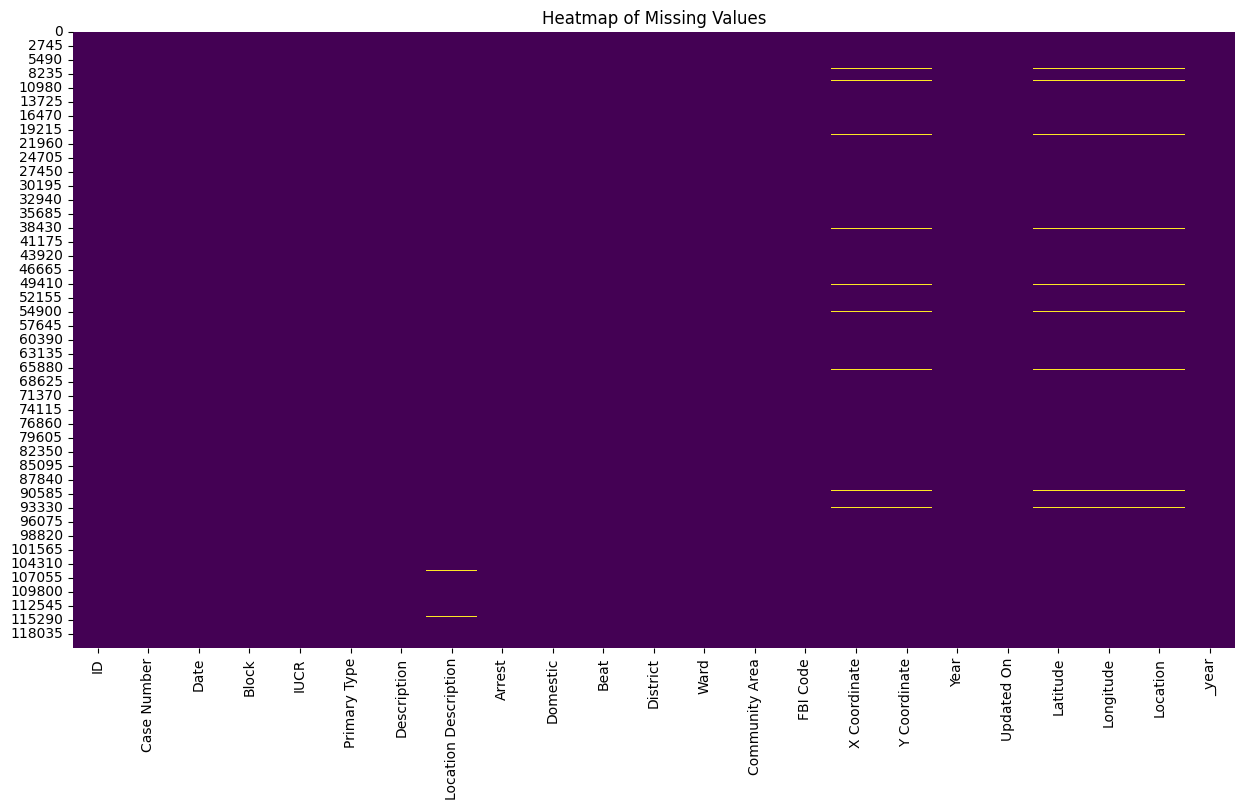

In [15]:
# Visualize missing values using a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

### Clean Up the Data

Remove any duplicate rows.

In [16]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Number of rows after removing duplicates: 120759


Fill in missing values. For fields like 'Community Area', 'Ward', 'District', and 'Location Description', we'll use 'Unknown'. For coordinates, we'll use 0.

In [17]:
# Fill missing categorical values with 'Unknown'
df['Community Area'] = df['Community Area'].astype(str).fillna('Unknown')
df['Ward'] = df['Ward'].astype(str).fillna('Unknown')
df['District'] = df['District'].astype(str).fillna('Unknown')
df['Location Description'] = df['Location Description'].fillna('Unknown')

# Fill missing numerical/coordinate values with 0
df['X Coordinate'] = df['X Coordinate'].fillna(0)
df['Y Coordinate'] = df['Y Coordinate'].fillna(0)
df['Latitude'] = df['Latitude'].fillna(0)
df['Longitude'] = df['Longitude'].fillna(0)
df['Location'] = df['Location'].fillna('(0.0, 0.0)')

print("All specified missing values handled.")

All specified missing values handled.


Check if there are still any missing values.

In [18]:
# Verify remaining missing values
missing_values_after_cleaning = df.isnull().sum()
print("Missing values after cleaning:")
display(missing_values_after_cleaning[missing_values_after_cleaning > 0])

Missing values after cleaning:


,0


Fill remaining missing 'Location Description' with 'Unknown'.

Confirm no missing values are left.

In [19]:
# Verify remaining missing values across the entire DataFrame
total_missing_after_all_cleaning = df.isnull().sum().sum()
if total_missing_after_all_cleaning == 0:
    print("All missing values have been handled. The DataFrame is now clean.")
else:
    print(f"There are still {total_missing_after_all_cleaning} missing values remaining.")
    display(df.isnull().sum()[df.isnull().sum() > 0])

All missing values have been handled. The DataFrame is now clean.


### See How Different Categories are Distributed

Let's look at the counts for 'Primary Type', 'Arrest', 'Location Description', 'District', and 'Ward'.

### Look at Time Trends

First, convert 'Date' to a proper date format and get the year, month, day of week, and hour.

In [20]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

# Extract temporal features
df['Year_Crime'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

print("Temporal features extracted successfully.")


Temporal features extracted successfully.


Now, let's plot crimes by year, month, day of week, and hour.

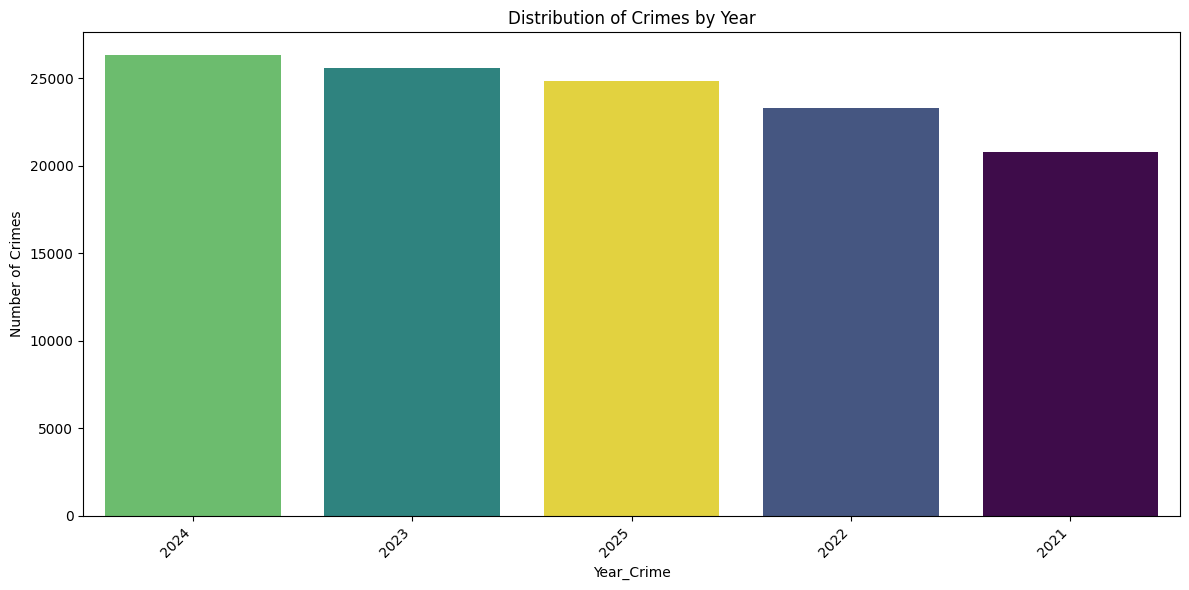

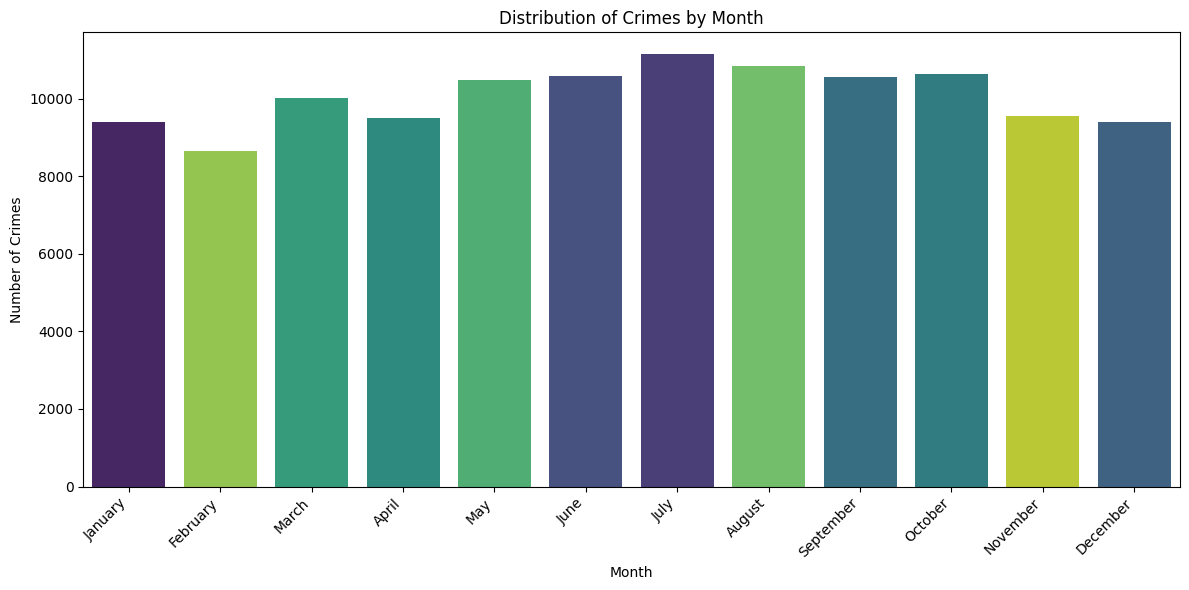

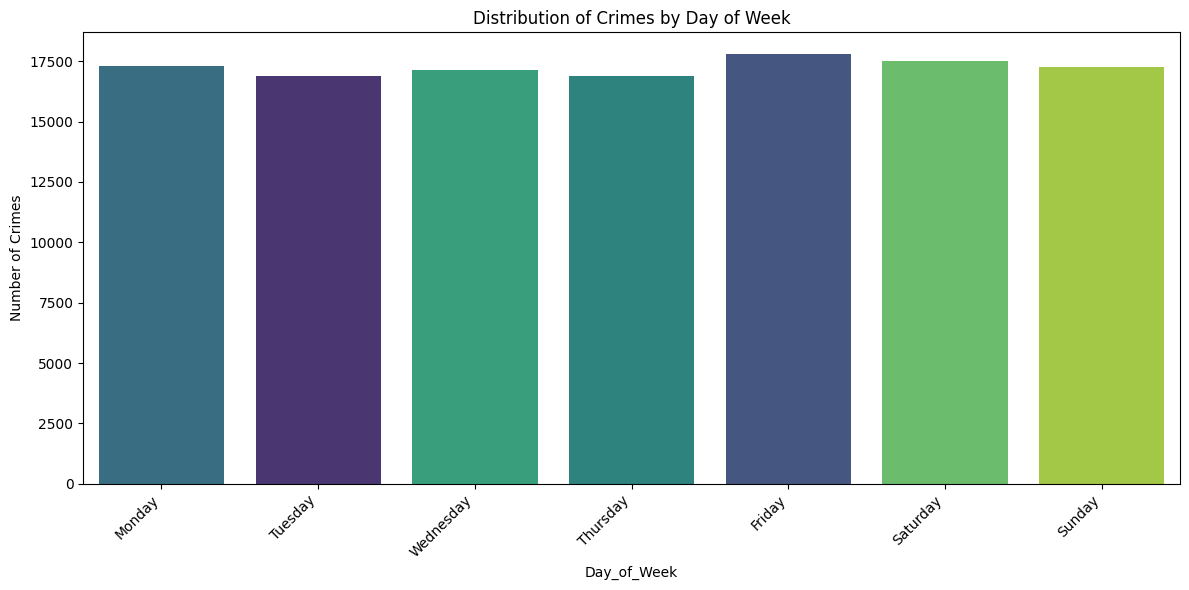

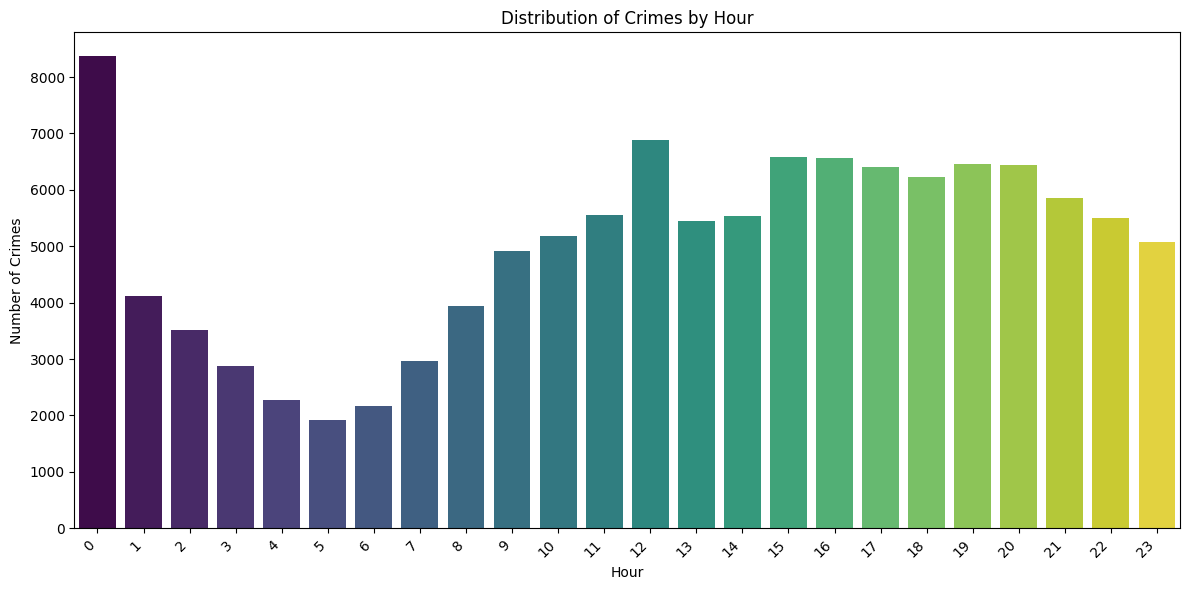

In [21]:
# Function to plot temporal distributions
def plot_temporal_distribution(dataframe, column, title, sort_order=None):
    plt.figure(figsize=(12, 6))
    if sort_order:
        order = sort_order
    else:
        order = dataframe[column].value_counts().index
    sns.countplot(x=column, data=dataframe, order=order, palette='viridis', hue=column, legend=False)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Number of Crimes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Distribution of crimes by Year
plot_temporal_distribution(df, 'Year_Crime', 'Distribution of Crimes by Year')

# Distribution of crimes by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plot_temporal_distribution(df, 'Month', 'Distribution of Crimes by Month', sort_order=month_order)

# Distribution of crimes by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plot_temporal_distribution(df, 'Day_of_Week', 'Distribution of Crimes by Day of Week', sort_order=day_order)

# Distribution of crimes by Hour
plot_temporal_distribution(df, 'Hour', 'Distribution of Crimes by Hour', sort_order=sorted(df['Hour'].unique()))

### How Crime Types Relate to Arrests

Let's see if certain crime types lead to more arrests. We'll use a bar chart and a heatmap.

### How Time Affects Arrests

See how arrest rates change over the years, months, days of the week, and hours of the day.

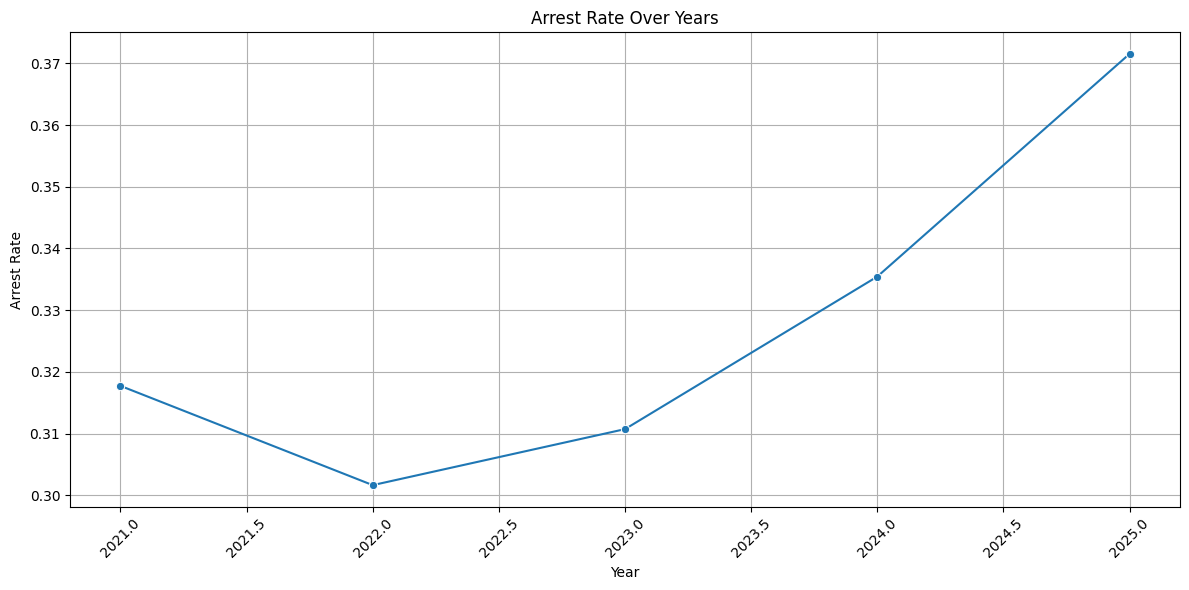

/tmp/ipykernel_2824/434838590.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Arrest', data=month_arrest_rate, palette='viridis')


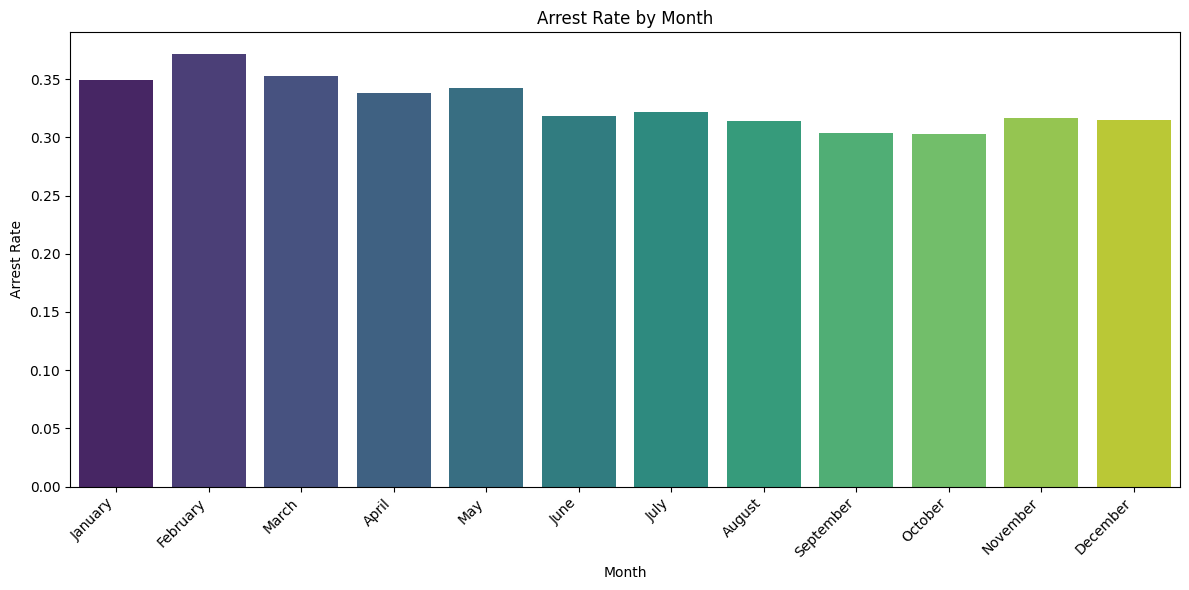

/tmp/ipykernel_2824/434838590.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Arrest', data=day_arrest_rate, palette='viridis')


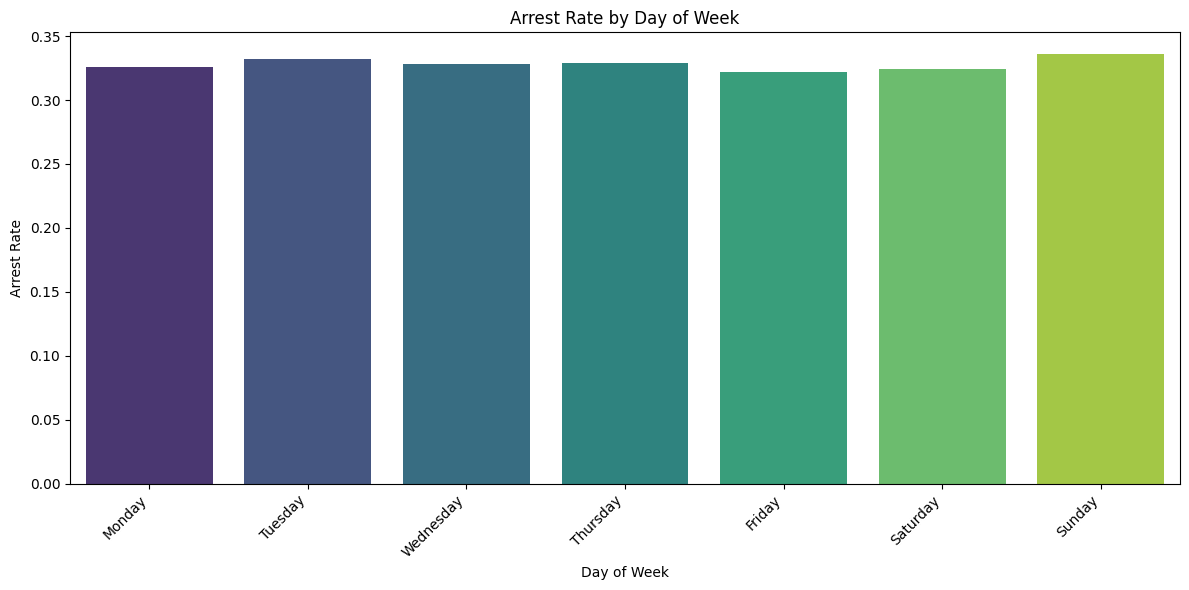

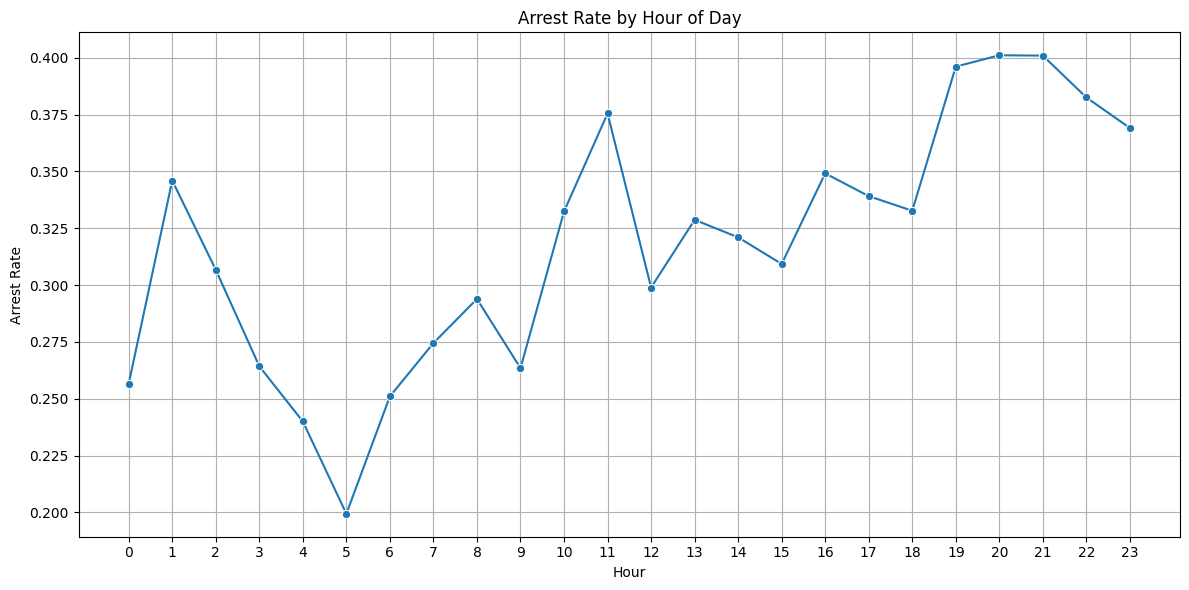

In [22]:
# Arrest rate by Year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year_Crime', y='Arrest', data=df.groupby('Year_Crime')['Arrest'].mean().reset_index(), marker='o')
plt.title('Arrest Rate Over Years')
plt.xlabel('Year')
plt.ylabel('Arrest Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Arrest rate by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_arrest_rate = df.groupby('Month')['Arrest'].mean().reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Arrest', data=month_arrest_rate, palette='viridis')
plt.title('Arrest Rate by Month')
plt.xlabel('Month')
plt.ylabel('Arrest Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Arrest rate by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_arrest_rate = df.groupby('Day_of_Week')['Arrest'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Day_of_Week', y='Arrest', data=day_arrest_rate, palette='viridis')
plt.title('Arrest Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Arrest Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Arrest rate by Hour
hour_arrest_rate = df.groupby('Hour')['Arrest'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Hour', y='Arrest', data=hour_arrest_rate, marker='o')
plt.title('Arrest Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Arrest Rate')
plt.grid(True)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

### Crime Patterns in Different Locations

Let's check what kind of crimes happen in different 'Location Description' and 'Community Area'.

### What We Found

This project analyzed Chicago crime data to understand basic patterns. We found common crime types like Theft and Battery, and saw that crime numbers have been decreasing recently. Arrest rates vary by crime type and time, with more arrests for some offenses than others. Locations also play a big role in what crimes occur where. This quick look helps us get a general idea of crime in Chicago.

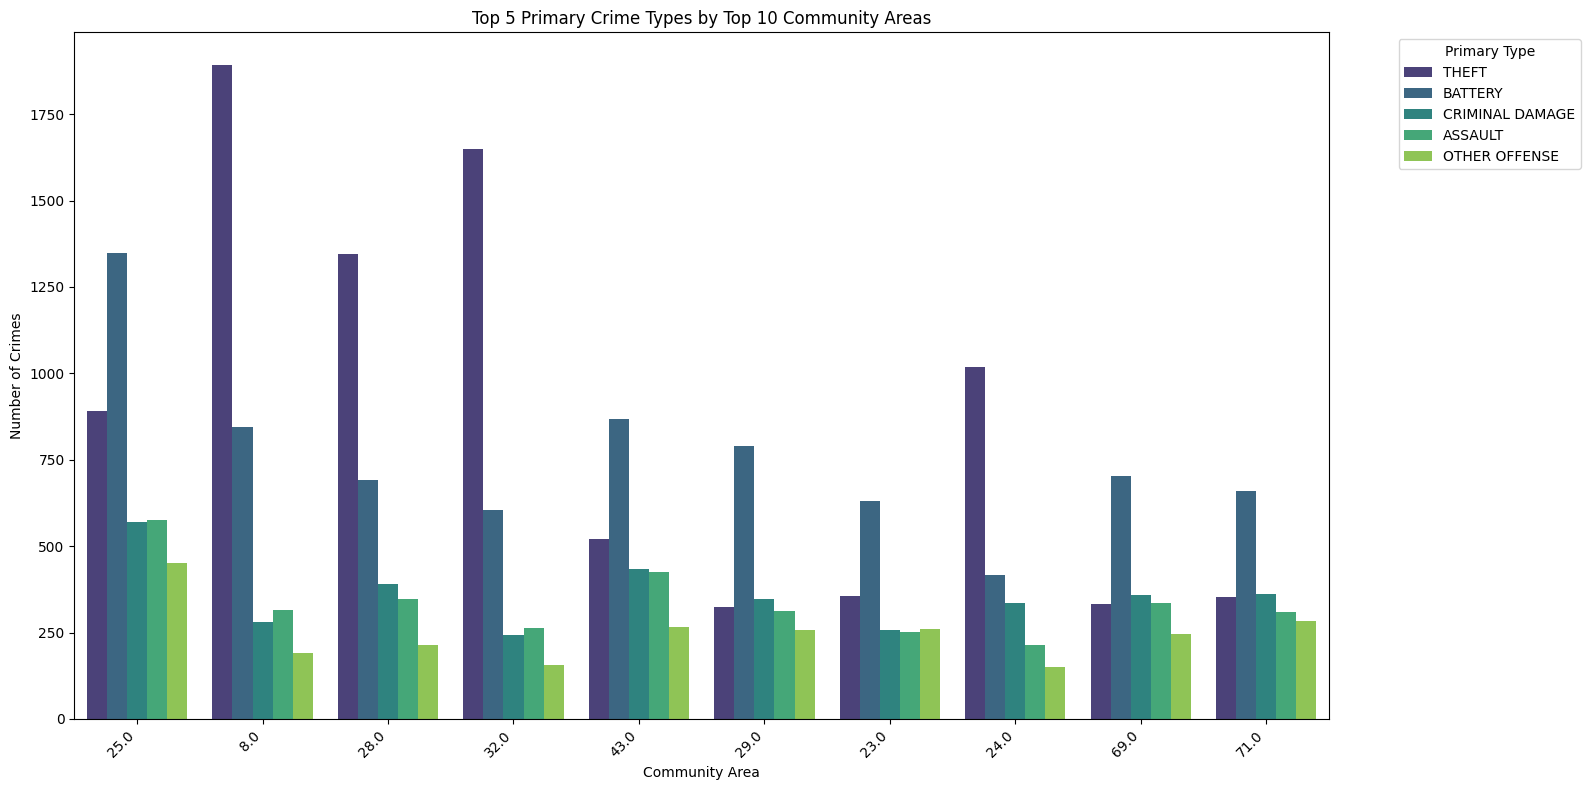

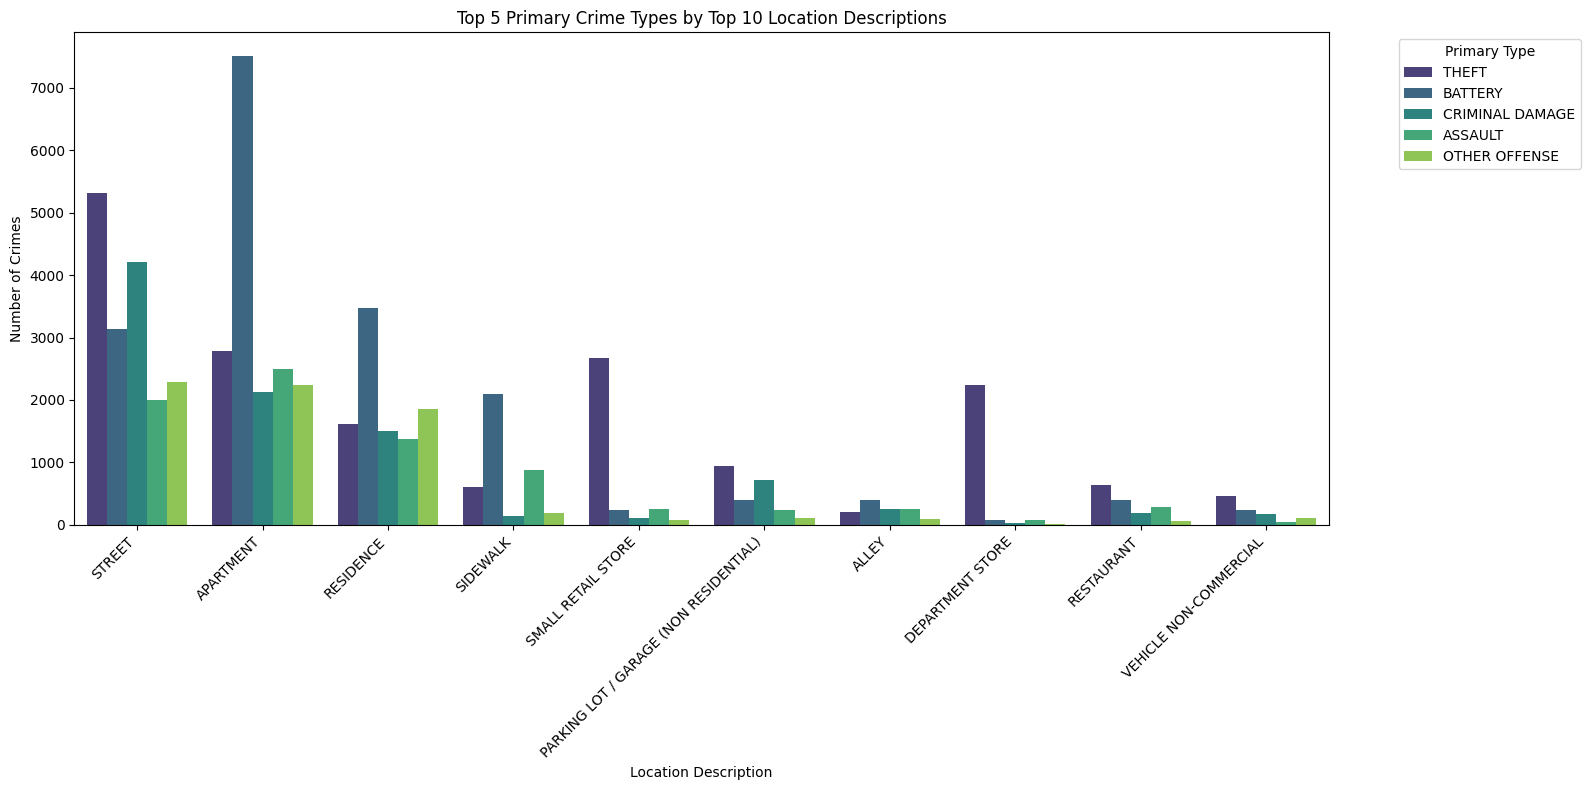

In [23]:
# Analyze top crime types by Community Area
# Get top 10 Community Areas excluding 'Unknown'
top_community_areas = df[df['Community Area'] != 'Unknown']['Community Area'].value_counts().nlargest(10).index

plt.figure(figsize=(16, 8))
sns.countplot(data=df[df['Community Area'].isin(top_community_areas)],
              x='Community Area', hue='Primary Type', palette='viridis',
              order=top_community_areas, hue_order=df['Primary Type'].value_counts().nlargest(5).index)
plt.title('Top 5 Primary Crime Types by Top 10 Community Areas')
plt.xlabel('Community Area')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Primary Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analyze top crime types by Location Description
# Get top 10 Location Descriptions excluding 'Unknown'
top_location_descriptions = df[df['Location Description'] != 'Unknown']['Location Description'].value_counts().nlargest(10).index

plt.figure(figsize=(16, 8))
sns.countplot(data=df[df['Location Description'].isin(top_location_descriptions)],
              x='Location Description', hue='Primary Type', palette='viridis',
              order=top_location_descriptions, hue_order=df['Primary Type'].value_counts().nlargest(5).index)
plt.title('Top 5 Primary Crime Types by Top 10 Location Descriptions')
plt.xlabel('Location Description')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Primary Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

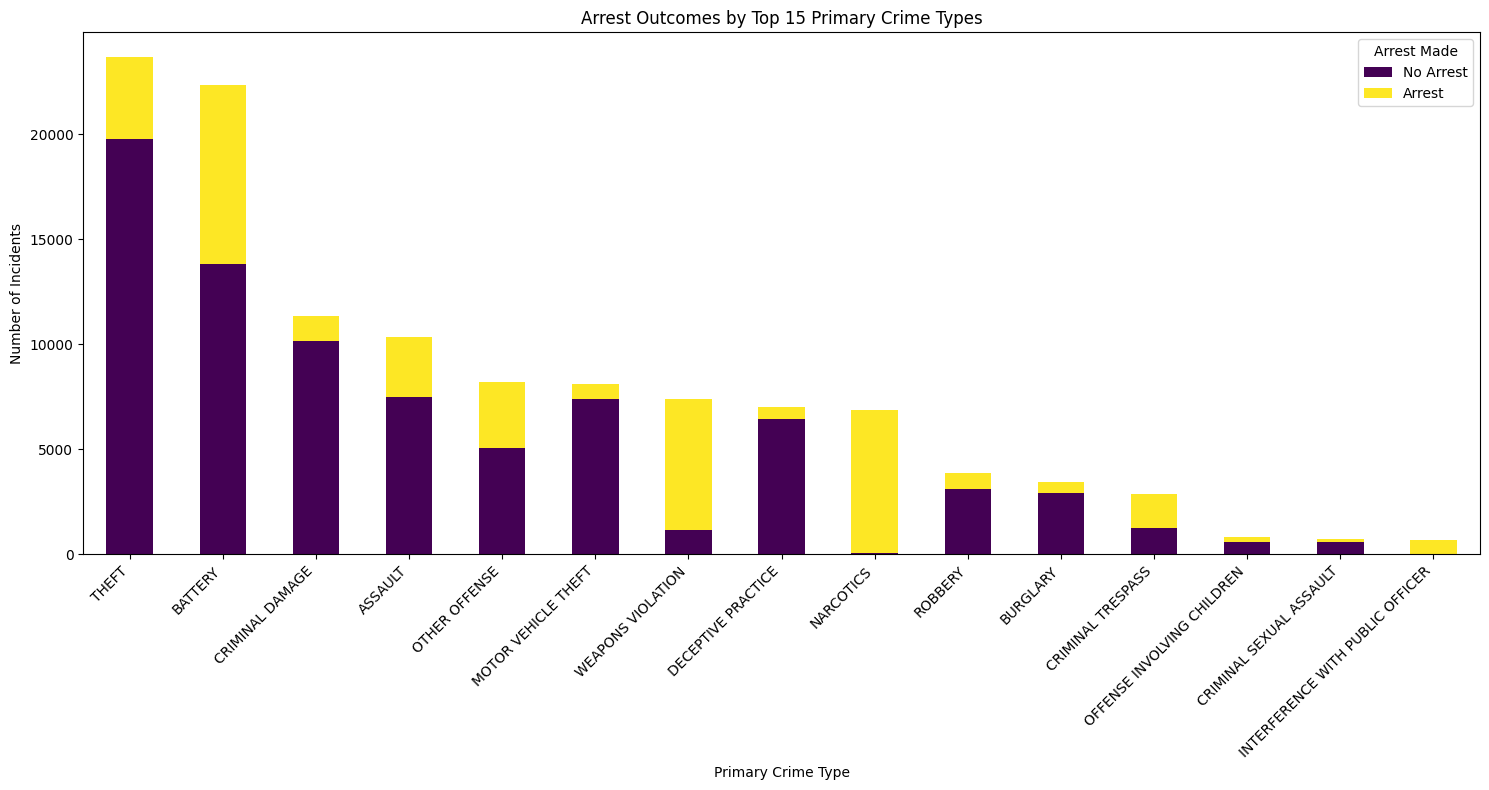

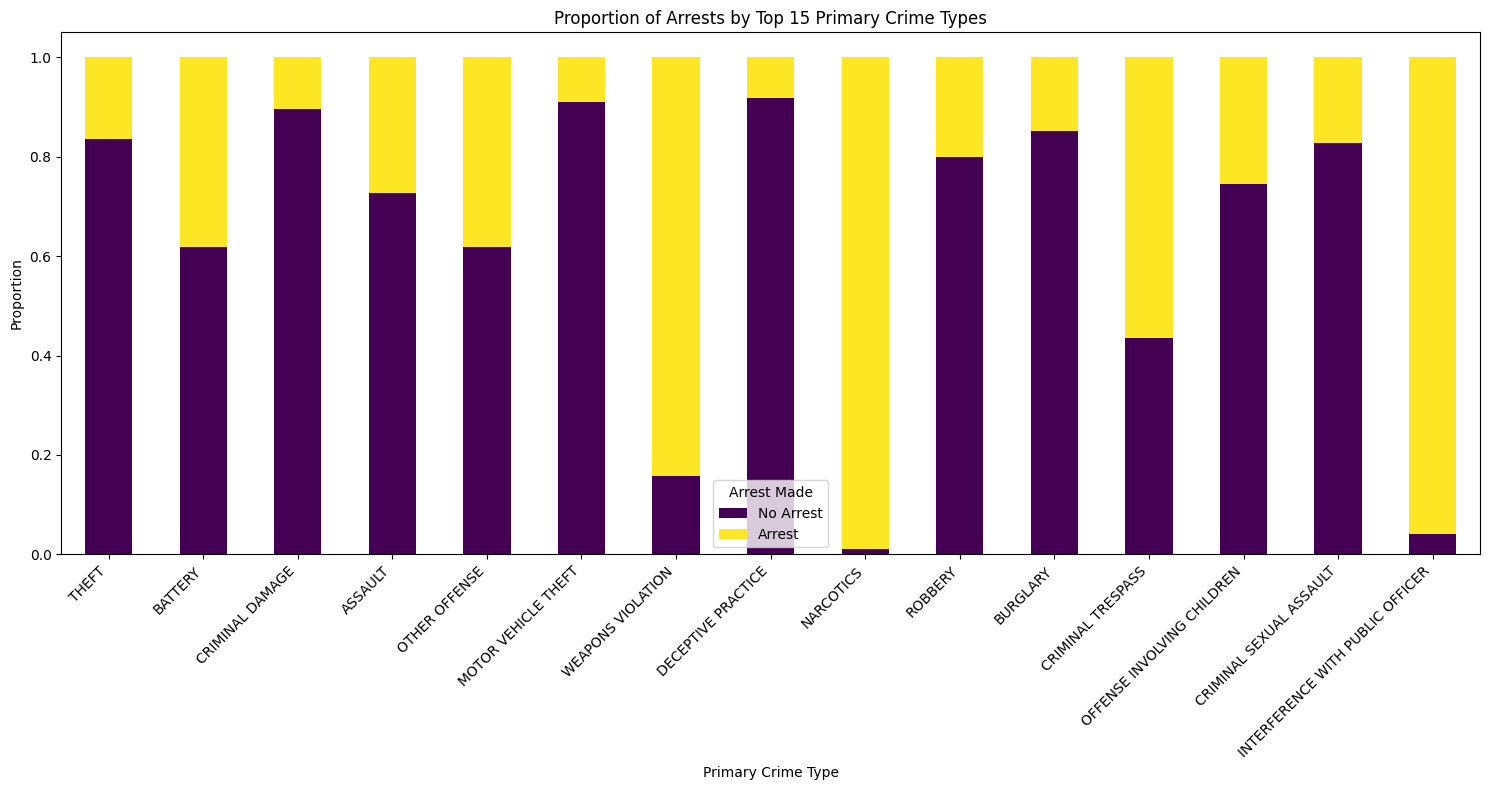

In [24]:
# Calculate the count of arrests per crime type
arrest_by_crime = df.groupby(['Primary Type', 'Arrest']).size().unstack(fill_value=0)

# Calculate the proportion of arrests for each crime type
arrest_proportion = arrest_by_crime.apply(lambda x: x / x.sum(), axis=1)

# Sort by total incidents for better visualization
arrest_by_crime_sorted = arrest_by_crime.sum(axis=1).sort_values(ascending=False).index
arrest_by_crime_plot = arrest_by_crime.loc[arrest_by_crime_sorted].head(15)

# Plotting stacked bar chart for top 15 crime types
arrest_by_crime_plot.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')
plt.title('Arrest Outcomes by Top 15 Primary Crime Types')
plt.xlabel('Primary Crime Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Arrest Made', labels=['No Arrest', 'Arrest'])
plt.tight_layout()
plt.show()

# Plotting the proportion of arrests as a stacked bar chart
arrest_proportion_plot = arrest_proportion.loc[arrest_by_crime_sorted].head(15)
arrest_proportion_plot.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')
plt.title('Proportion of Arrests by Top 15 Primary Crime Types')
plt.xlabel('Primary Crime Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Arrest Made', labels=['No Arrest', 'Arrest'])
plt.tight_layout()
plt.show()

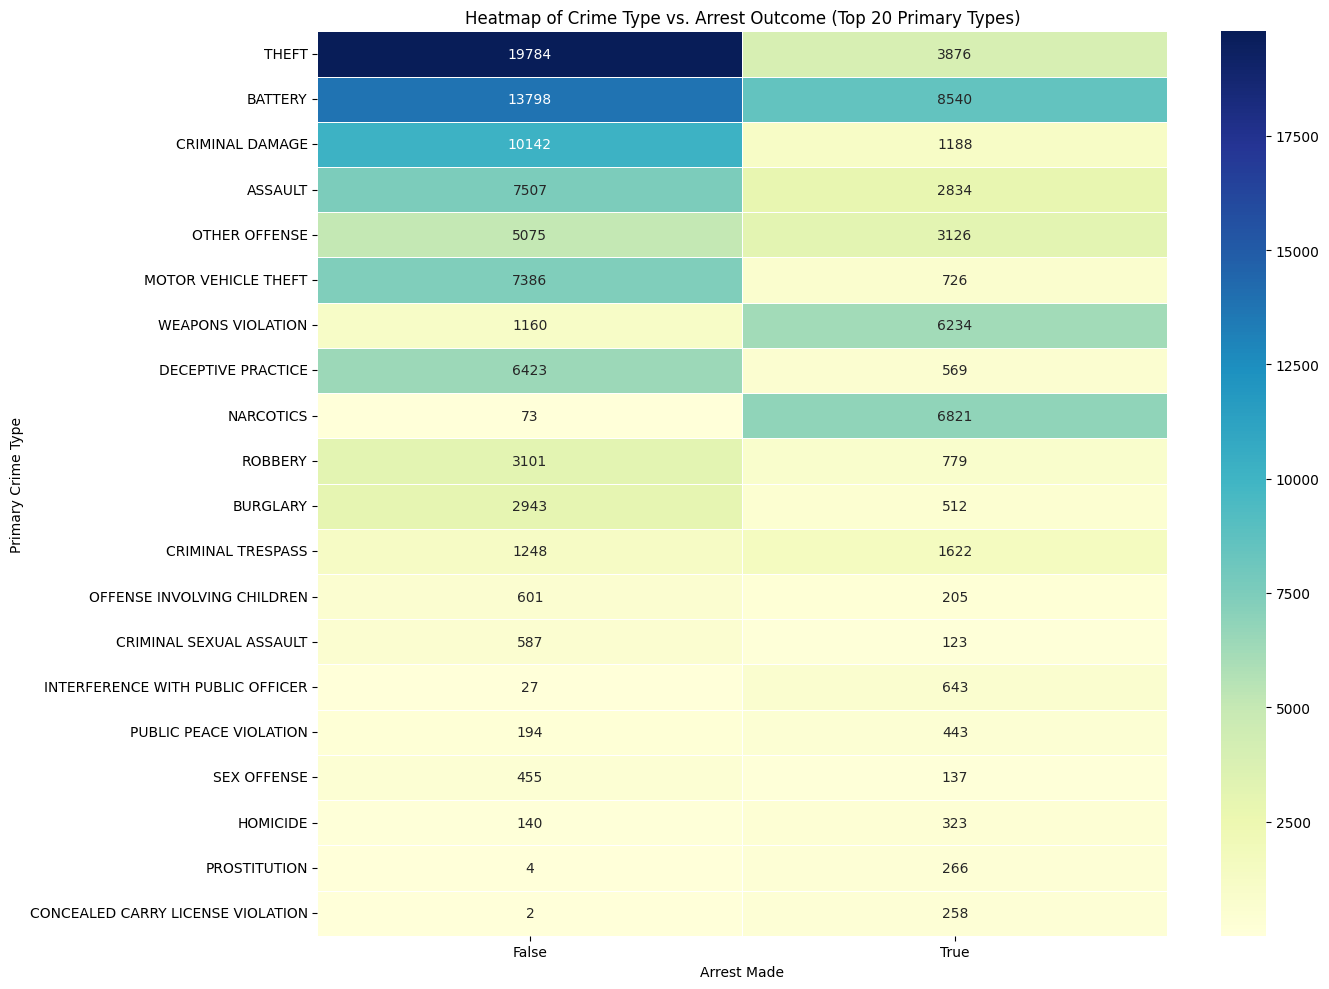

In [25]:
# Create a cross-tabulation (contingency table) of Primary Type and Arrest
crosstab_df = pd.crosstab(df['Primary Type'], df['Arrest'])

# Filter for top N crime types to make the heatmap readable
top_n_crimes = df['Primary Type'].value_counts().nlargest(20).index
crosstab_filtered = crosstab_df.loc[top_n_crimes]

plt.figure(figsize=(14, 10))
sns.heatmap(crosstab_filtered, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Crime Type vs. Arrest Outcome (Top 20 Primary Types)')
plt.xlabel('Arrest Made')
plt.ylabel('Primary Crime Type')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2824/118166481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


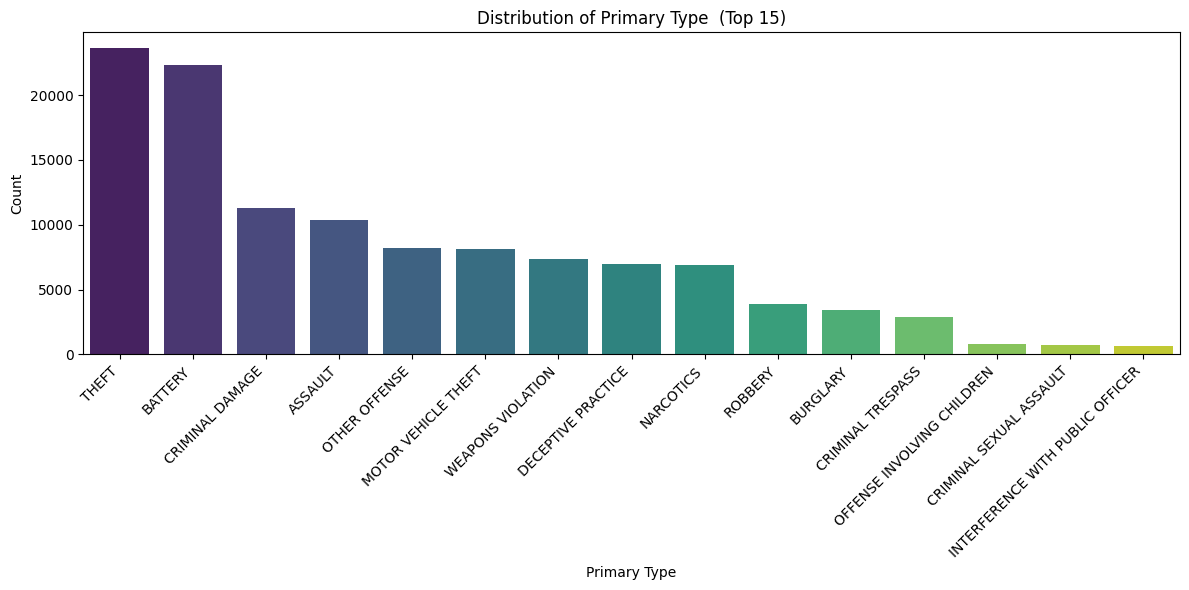

/tmp/ipykernel_2824/118166481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


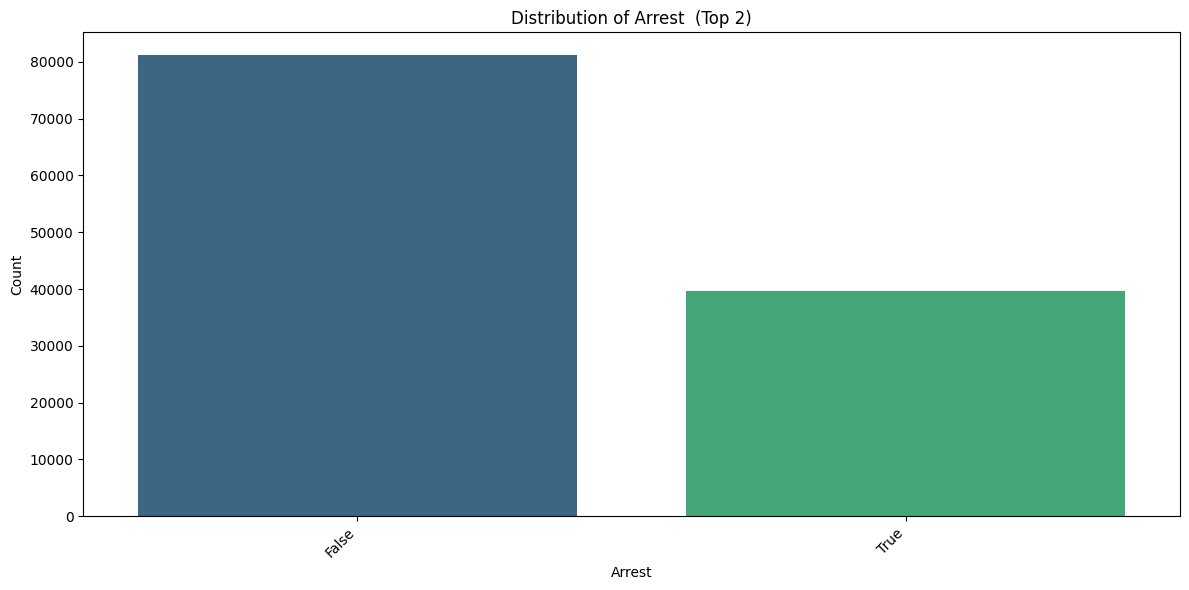

/tmp/ipykernel_2824/118166481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


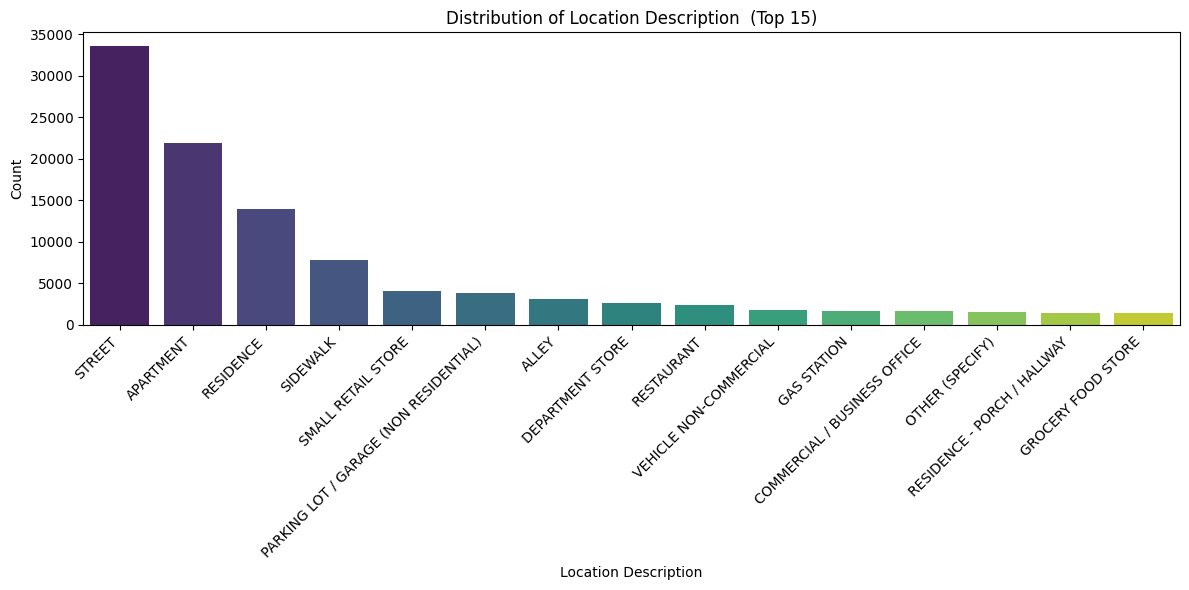

/tmp/ipykernel_2824/118166481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


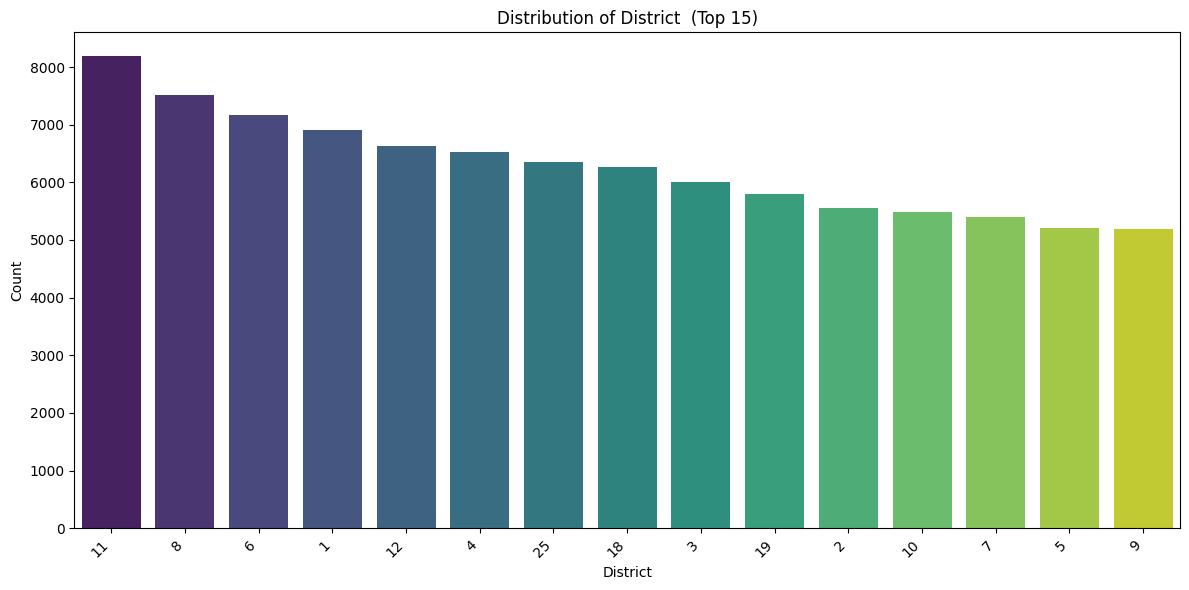

/tmp/ipykernel_2824/118166481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')


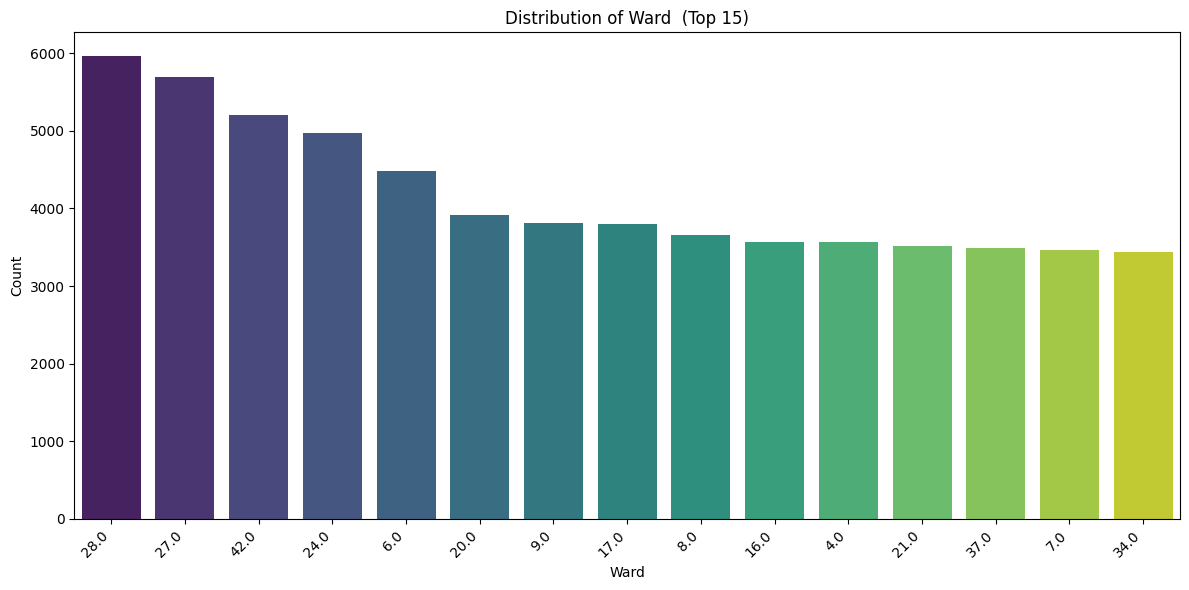

In [26]:
# Function to plot value counts for categorical columns
def plot_categorical_distribution(dataframe, column, title_suffix='', top_n=10):
    plt.figure(figsize=(12, 6))
    # Get top_n values for plotting
    top_values = dataframe[column].value_counts().nlargest(top_n)
    sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
    plt.title(f'Distribution of {column} {title_suffix} (Top {top_n})')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Analyze 'Primary Type'
plot_categorical_distribution(df, 'Primary Type', top_n=15)

# Analyze 'Arrest'
plot_categorical_distribution(df, 'Arrest', top_n=2)

# Analyze 'Location Description'
plot_categorical_distribution(df, 'Location Description', top_n=15)

# Analyze 'District' (convert to object for categorical plotting if not already)
df['District'] = df['District'].astype(str)
plot_categorical_distribution(df, 'District', top_n=15)

# Analyze 'Ward' (convert to object for categorical plotting if not already)
df['Ward'] = df['Ward'].astype(str)
plot_categorical_distribution(df, 'Ward', top_n=15)

In [27]:
# Fill remaining missing 'Location Description' with 'Unknown'
df['Location Description'] = df['Location Description'].fillna('Unknown')

print("Missing values in 'Location Description' handled.")

Missing values in 'Location Description' handled.
